# LIGO GW Signal Search Pipeline

Search for a compact-binary coalescence chirp in LIGO Livingston (L1) strain data, measure its properties, and produce diagnostic plots.

**Data**: `LIGODATA_L.txt` — 131,072 samples at 4096 Hz (32 s).
**Outputs**: `figures/*.png` and a printed parameter report.

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import median_filter

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------
FS = 4096.0                 # Sampling rate (Hz)
NYQUIST = FS / 2.0          # Nyquist frequency (Hz)

# Auto-detect data file: searches cwd and up to 3 parent directories.
def _find_data(filename='LIGODATA_L.txt'):
    current = os.getcwd()
    for _ in range(4):
        path = os.path.join(current, filename)
        if os.path.isfile(path):
            return path
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise FileNotFoundError(
        f"{filename} not found in {os.getcwd()} or its parents. "
        "Please set DATA_FILE to the full path."
    )

DATA_FILE = _find_data('LIGODATA_L.txt')
print(f'Using data file: {DATA_FILE}')

FIG_DIR = 'figures'

# Band-pass range for compact-binary chirp (Hz)
F_LOW = 30.0
F_HIGH = 400.0

# Physical constants for chirp-mass estimation
G = 6.67430e-11             # m^3 kg^-1 s^-2
C = 2.99792458e8            # m/s
MSUN = 1.98847e30           # kg

os.makedirs(FIG_DIR, exist_ok=True)
print("Setup complete.")

Using data file: /workspace/LIGODATA_L.txt
Setup complete.


## 1. Data Loading

Read the strain time series and build the time array.

In [15]:
h = np.loadtxt(DATA_FILE)
n = len(h)
t = np.arange(n) / FS
print(f"Loaded {n:,} samples  ({n/FS:.2f} s at {FS:.0f} Hz)")

Loaded 131,072 samples  (32.00 s at 4096 Hz)


## 2. Raw Inspection

Plot the raw time series, the power spectral density (PSD), and a spectrogram.

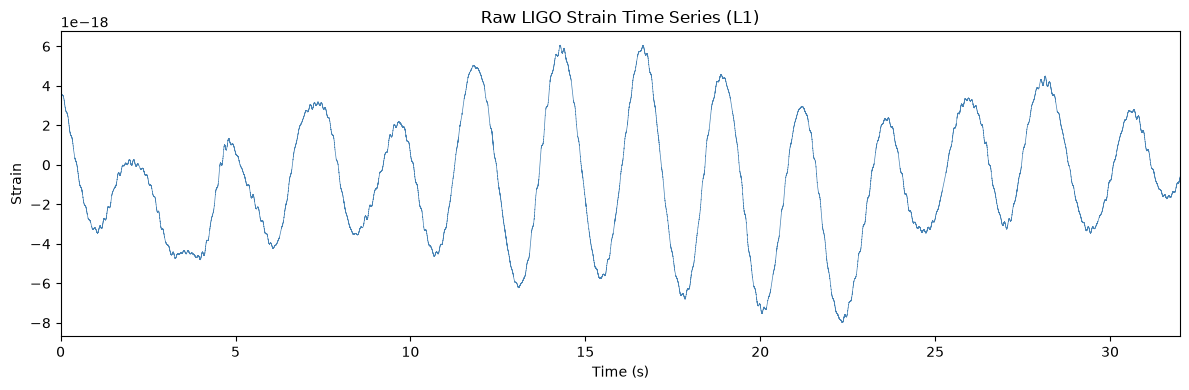

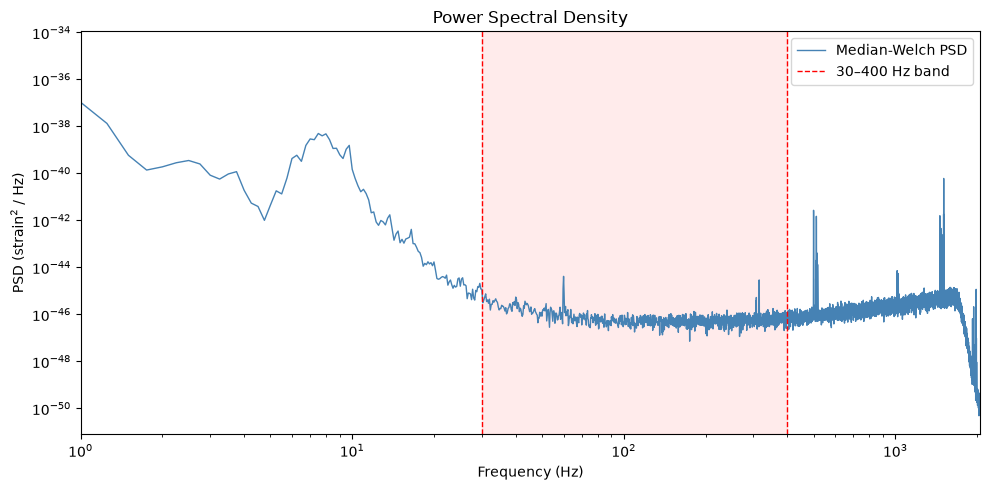

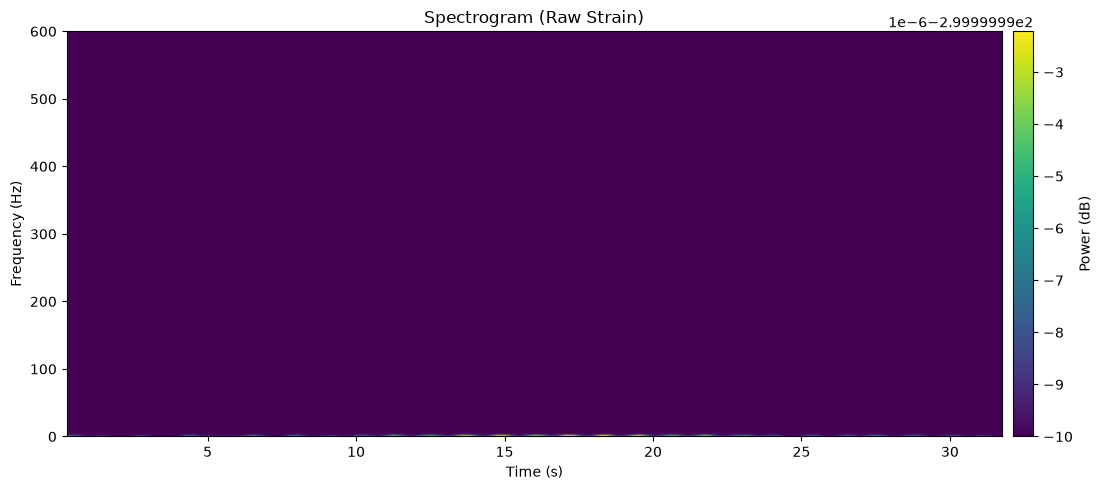

In [16]:
# --- Raw time series ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, h, color='steelblue', lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')
ax.set_title('Raw LIGO Strain Time Series (L1)')
ax.set_xlim(t[0], t[-1])
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '01_raw_timeseries.png'), dpi=150)
plt.show()

# --- PSD ---
seglen = int(4 * FS)
freqs, psd = signal.welch(h, FS, nperseg=seglen, window='hann',
                          noverlap=seglen//2, average='median')

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(freqs, psd, color='steelblue', lw=1.0, label='Median-Welch PSD')
ax.axvline(F_LOW, color='red', ls='--', lw=1, label=f'{F_LOW:.0f}–{F_HIGH:.0f} Hz band')
ax.axvline(F_HIGH, color='red', ls='--', lw=1)
ax.axvspan(F_LOW, F_HIGH, color='red', alpha=0.08)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'PSD (strain$^2$ / Hz)')
ax.set_title('Power Spectral Density')
ax.set_xlim([1, NYQUIST])
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '02_psd.png'), dpi=150)
plt.show()

# --- Spectrogram ---
nperseg = int(0.5 * FS)
f, time_bins, Sxx = signal.spectrogram(
    h, FS, window='hann', nperseg=nperseg,
    noverlap=nperseg//2, scaling='spectrum'
)
fmax_plot = 600.0
idx_f = f <= fmax_plot
Sxx_dB = 10 * np.log10(Sxx[idx_f, :] + 1e-30)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(time_bins, f[idx_f], Sxx_dB,
                   shading='gouraud', cmap='viridis')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Spectrogram (Raw Strain)')
ax.set_ylim([0, fmax_plot])
fig.colorbar(im, ax=ax, pad=0.01, label='Power (dB)')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '03_spectrogram_raw.png'), dpi=150)
plt.show()

## 3. Data Cleaning

Apply a zero-phase Butterworth band-pass filter (30–400 Hz) and whiten the strain using a smooth noise PSD estimate.

In [17]:
def bandpass(h, f_low=F_LOW, f_high=F_HIGH, order=4):
    """Zero-phase Butterworth band-pass filter."""
    sos = signal.butter(order, [f_low, f_high], btype='band',
                        fs=FS, output='sos')
    return signal.sosfiltfilt(sos, h)


def whiten(h, freqs=None, psd=None):
    """
    Whiten the strain time series.

    Divides the frequency-domain data by the amplitude spectral density
    (sqrt(PSD)) so that the noise PSD becomes flat (white).  The output
    is normalised such that stationary Gaussian noise has time-domain
    standard deviation ≈ 1.
    """
    n = len(h)

    # Tukey window to reduce spectral leakage from the implicit boxcar
    window = signal.windows.tukey(n, alpha=0.1)
    hf = np.fft.rfft(h * window)
    freq_rfft = np.fft.rfftfreq(n, d=1.0 / FS)

    # Estimate PSD if not supplied
    if freqs is None or psd is None:
        freqs, psd = signal.welch(
            h, FS, nperseg=int(4 * FS), window='hann',
            noverlap=int(2 * FS), average='median',
        )

    # Interpolate PSD onto the FFT frequency grid
    psd_interp = np.interp(
        freq_rfft, freqs, psd, left=psd[0], right=psd[-1],
    )
    # Floor to avoid division by zero
    psd_interp = np.maximum(psd_interp, np.max(psd_interp) * 1e-12)

    # Whiten: divide by ASD and normalise for ≈ unit time-domain variance
    asd = np.sqrt(psd_interp)
    hf_white = hf / asd * np.sqrt(2.0 / FS)

    # Zero out DC / Nyquist bins (carry no useful signal)
    hf_white[0] = 0.0
    if n % 2 == 0:
        hf_white[-1] = 0.0

    return np.fft.irfft(hf_white, n=n)


# Apply filters
h_bp = bandpass(h)
h_white = whiten(h, freqs=freqs, psd=psd)
h_white_bp = bandpass(h_white)
print("Band-pass and whitening complete.")

Band-pass and whitening complete.


## 4. Signal Identification

Locate the merger from the peak of the whitened strain and inspect the cleaned spectrogram.

Merger candidate at t = 10.7686 s


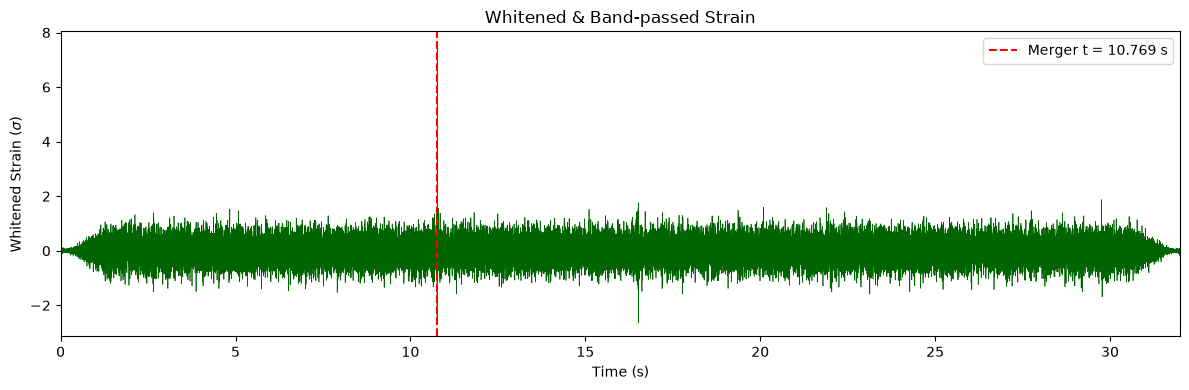

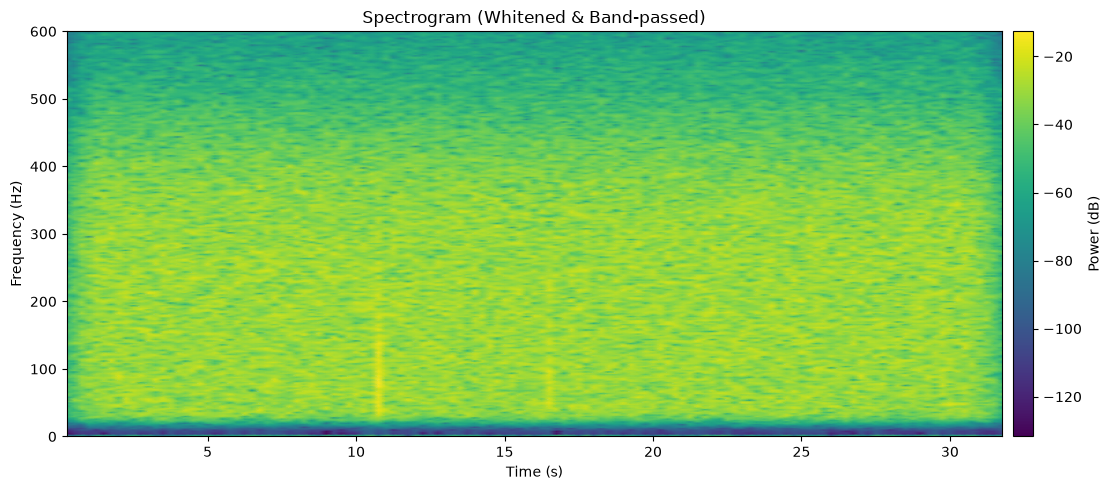

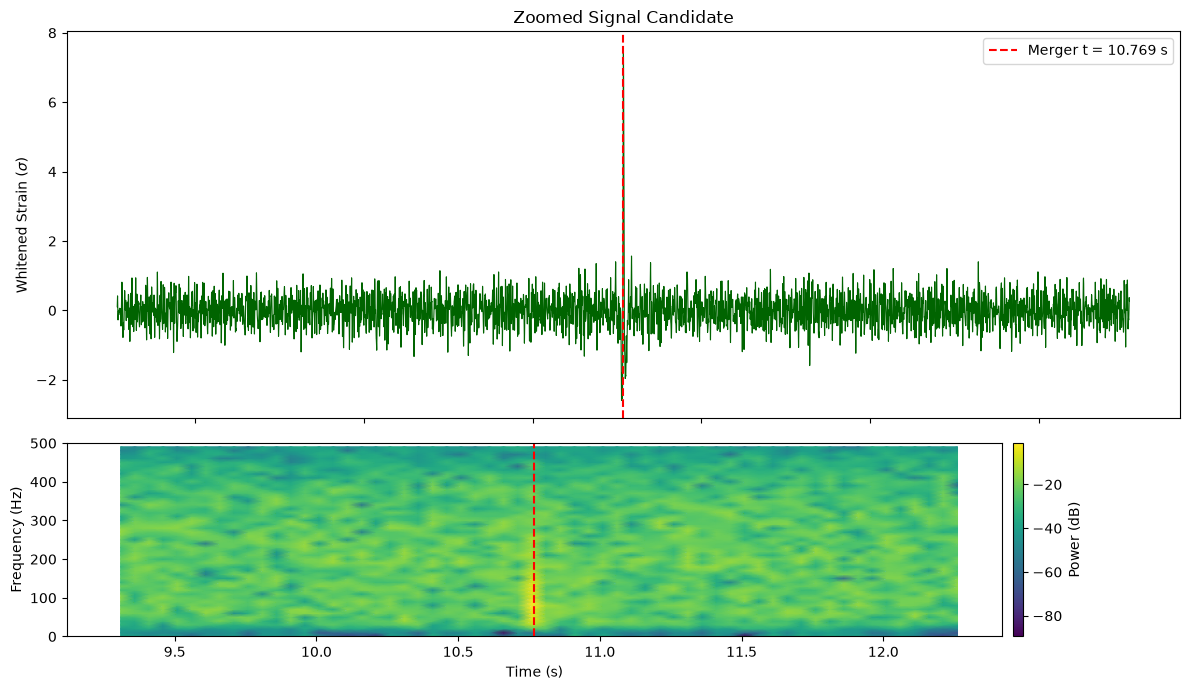

In [18]:
# Find merger time from the peak of |whitened & bandpassed strain|,
# excluding the edges to avoid filter startup transients
edge_skip = int(0.5 * FS)                # 0.5 s at each end
idx_peak = edge_skip + np.argmax(np.abs(h_white_bp[edge_skip:-edge_skip]))
t_peak = t[idx_peak]
print(f"Merger candidate at t = {t_peak:.4f} s")

# Whitened time series plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, h_white_bp, color='darkgreen', lw=0.5)
ax.axvline(t_peak, color='red', ls='--', lw=1.5, label=f'Merger t = {t_peak:.3f} s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Whitened Strain ($\\sigma$)')
ax.set_title('Whitened & Band-passed Strain')
ax.set_xlim(t[0], t[-1])
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '04_whitened_timeseries.png'), dpi=150)
plt.show()

# Whitened spectrogram
f_w, time_bins_w, Sxx_w = signal.spectrogram(
    h_white_bp, FS, window='hann', nperseg=nperseg,
    noverlap=nperseg//2, scaling='spectrum'
)
idx_f_w = f_w <= fmax_plot
Sxx_w_dB = 10 * np.log10(Sxx_w[idx_f_w, :] + 1e-30)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(time_bins_w, f_w[idx_f_w], Sxx_w_dB,
                   shading='gouraud', cmap='viridis')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Spectrogram (Whitened & Band-passed)')
ax.set_ylim([0, fmax_plot])
fig.colorbar(im, ax=ax, pad=0.01, label='Power (dB)')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '05_spectrogram_whitened.png'), dpi=150)
plt.show()

# Zoomed view around the merger
zoom_pad = 1.5
z0 = max(0, int((t_peak - zoom_pad) * FS))
z1 = min(len(t), int((t_peak + zoom_pad) * FS))
t_zoom = t[z0:z1]
h_zoom = h_white_bp[z0:z1]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(t_zoom, h_zoom, color='darkgreen', lw=0.8)
axes[0].axvline(t_peak, color='red', ls='--', lw=1.5, label=f'Merger t = {t_peak:.3f} s')
axes[0].set_ylabel('Whitened Strain ($\\sigma$)')
axes[0].set_title('Zoomed Signal Candidate')
axes[0].legend()

nperseg_zoom = int(0.1 * FS)
f_z, t_z, Sxx_z = signal.spectrogram(
    h_white_bp, FS, window='hann', nperseg=nperseg_zoom,
    noverlap=nperseg_zoom//2, scaling='spectrum'
)
tmask = (t_z >= t_peak - zoom_pad) & (t_z <= t_peak + zoom_pad)
fmask = f_z <= 500
Sxx_z_dB = 10 * np.log10(Sxx_z[np.ix_(fmask, tmask)] + 1e-30)
im = axes[1].pcolormesh(t_z[tmask], f_z[fmask], Sxx_z_dB,
                        shading='gouraud', cmap='viridis')
axes[1].axvline(t_peak, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim([0, 500])
fig.colorbar(im, ax=axes[1], pad=0.01, label='Power (dB)')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '06_signal_zoom.png'), dpi=150)
plt.show()

## 5. Parameter Measurement

Estimate SNR, duration in band, frequency range, and chirp mass.

In [19]:
# --- SNR ---
# Use the whitened+bandpassed data for both noise σ and peak amplitude.
# Exclude a 2 s guard zone around the merger and the edge-skip regions.
guard = int(2.0 * FS)               # 2 s guard around the peak
signal_zone = slice(max(0, idx_peak - guard),
                    min(len(t), idx_peak + guard))
noise_mask = np.ones(len(t), dtype=bool)
noise_mask[signal_zone] = False
noise_mask[:edge_skip] = False       # exclude filter start-up transient
noise_mask[-edge_skip:] = False      # exclude filter end transient

sigma = np.std(h_white_bp[noise_mask])
peak_amp = np.abs(h_white_bp[idx_peak])
snr = peak_amp / sigma
print(f"Peak whitened amplitude : {peak_amp:.2f}")
print(f"Off-source noise σ      : {sigma:.3f}")
print(f"SNR estimate            : {snr:.1f}")

# --- Duration & frequency track ---
# Work on a wide segment to capture the full inspiral.
seg_before = 3.0                     # look up to 3 s before merger
seg_after  = 0.5                     # 0.5 s after merger
s0 = max(0,         int((t_peak - seg_before) * FS))
s1 = min(len(t),    int((t_peak + seg_after)  * FS))
h_seg = h_white_bp[s0:s1]
t_seg = t[s0:s1]

analytic   = signal.hilbert(h_seg)
inst_amp   = np.abs(analytic)
phase      = np.unwrap(np.angle(analytic))
inst_freq  = np.diff(phase) / (2.0 * np.pi) * FS
inst_freq  = np.append(inst_freq, inst_freq[-1])

# Inspiral start: amplitude first exceeds 10 % of peak
amp_norm      = inst_amp / np.max(inst_amp)
above_thresh  = np.where(amp_norm > 0.1)[0]
t_inspiral_start = t_seg[above_thresh[0]] if len(above_thresh) > 0 else t_seg[0]
duration = t_peak - t_inspiral_start

# Frequency range during the inspiral phase only
idx_peak_seg = np.argmax(inst_amp)
if idx_peak_seg > 0 and len(above_thresh) > 0:
    f_inspiral = inst_freq[above_thresh[0]:idx_peak_seg]
    # Clip to the band-pass range to reject filter roll-off artefacts
    f_inspiral = f_inspiral[(f_inspiral >= F_LOW) & (f_inspiral <= F_HIGH)]
    if len(f_inspiral) > 5:
        f_min = np.percentile(f_inspiral, 5)
        f_max = np.percentile(f_inspiral, 95)
    else:
        f_min = f_max = np.nan
else:
    f_min = f_max = np.nan

print(f"Duration in band : {duration:.4f} s")
print(f"Frequency range  : {f_min:.1f} – {f_max:.1f} Hz")

# --- Chirp mass ---
# Smooth the instantaneous frequency, then estimate df/dt and invert
# the Newtonian chirp relation.
f_smooth = median_filter(inst_freq, size=5)
df_dt    = np.gradient(f_smooth, t_seg)
valid    = (df_dt > 0) & (f_smooth > F_LOW) & (f_smooth < F_HIGH)

if np.sum(valid) >= 5:
    f_v    = f_smooth[valid]
    dfdt_v = df_dt[valid]
    # M_c = (c³/G) · [ (5/96) π^{-8/3} f^{-11/3} df/dt ]^{3/5}
    coeff     = (5.0 / 96.0) * np.pi**(-8.0/3.0) * f_v**(-11.0/3.0) * dfdt_v
    M_c_kg    = (C**3 / G) * coeff**(3.0/5.0)
    M_c_msun  = M_c_kg / MSUN
    chirp_mass = float(np.median(M_c_msun))
    print(f"Chirp mass (M_c) : {chirp_mass:.2f} M☉")
else:
    chirp_mass = np.nan
    print("Chirp mass: could not be estimated")

Peak whitened amplitude : 7.54
Off-source noise σ      : 0.395
SNR estimate            : 19.1
Duration in band : 2.9575 s
Frequency range  : 80.9 – 340.3 Hz
Chirp mass (M_c) : 28.38 M☉


## 6. Results Summary

In [20]:
print("=" * 50)
print("RESULTS")
print("=" * 50)
print(f"Merger time          : {t_peak:.4f} s")
print(f"Duration in band     : {duration:.4f} s")
print(f"Frequency range      : {f_min:.1f} – {f_max:.1f} Hz")
print(f"Peak whitened amp    : {peak_amp:.2f} σ")
print(f"Noise σ (reference)  : {sigma:.3f}")
print(f"SNR estimate         : {snr:.1f}")
if not np.isnan(chirp_mass):
    print(f"Chirp mass (M_c)     : {chirp_mass:.2f} M☉")
else:
    print("Chirp mass (M_c)     : could not be estimated")
print("=" * 50)
print(f"Figures saved to ./{FIG_DIR}/")

RESULTS
Merger time          : 10.7686 s
Duration in band     : 2.9575 s
Frequency range      : 80.9 – 340.3 Hz
Peak whitened amp    : 7.54 σ
Noise σ (reference)  : 0.395
SNR estimate         : 19.1
Chirp mass (M_c)     : 28.38 M☉
Figures saved to ./figures/
